# Taxi Fare Prediction

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score



In [6]:
df = pd.read_csv('taxi_trips.csv')
df.head()

,trip_id,pickup_datetime,pickup_zone,vehicle_type,passenger_count,trip_distance_km,trip_duration_min,payment_method,fare_amount
0,TRP103884,2024-08-14 00:08:34,Suburb,SUV,3,4.25,10.3,Cash,265.88
1,TRP110195,2025-03-23 01:41:05,Business District,Mini,1,2.74,12.9,Card,153.71
2,TRP105034,2024-10-26 13:02:19,Residential,Mini,1,4.30,12.4,Cash,110.97
3,TRP102638,2025-04-10 06:30:44,Residential,Sedan,3,2.67,7.2,UPI,113.50
4,TRP109202,2025-01-17 03:46:57,Business District,Auto,1,8.18,28.6,Cash,149.64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12060 entries, 0 to 12059
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   trip_id            12060 non-null  object 
 1   pickup_datetime    12060 non-null  object 
 2   pickup_zone        12060 non-null  object 
 3   vehicle_type       12060 non-null  object 
 4   passenger_count    12060 non-null  int64  
 5   trip_distance_km   12060 non-null  float64
 6   trip_duration_min  11988 non-null  float64
 7   payment_method     12060 non-null  object 
 8   fare_amount        12060 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 848.1+ KB


In [9]:
df.describe()

,passenger_count,trip_distance_km,trip_duration_min,fare_amount
count,12060.000000,12060.000000,11988.000000,12060.000000
mean,1.990713,5.183643,18.953003,192.386823
std,1.263092,3.565338,12.129679,134.401974
min,0.000000,0.500000,3.000000,30.000000
25%,1.000000,2.820000,11.200000,125.477500
50%,2.000000,4.215000,15.700000,170.865000
75%,3.000000,6.470000,22.900000,229.210000
max,6.000000,48.000000,156.800000,4941.684481


In [11]:
print("Shape:", df.shape)


Shape: (12060, 9)


In [14]:
missing = df.isnull().sum()
print(missing)

trip_id               0
pickup_datetime       0
pickup_zone           0
vehicle_type          0
passenger_count       0
trip_distance_km      0
trip_duration_min    72
payment_method        0
fare_amount           0
dtype: int64


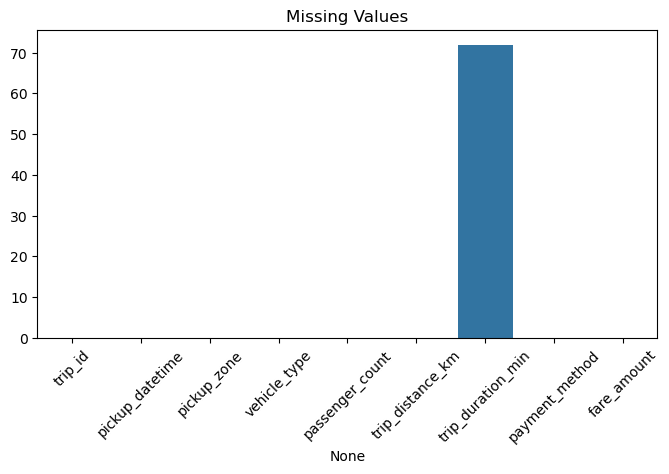

In [ ]:
#Missing Values
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=45)
plt.title("Missing Values")
plt.show()

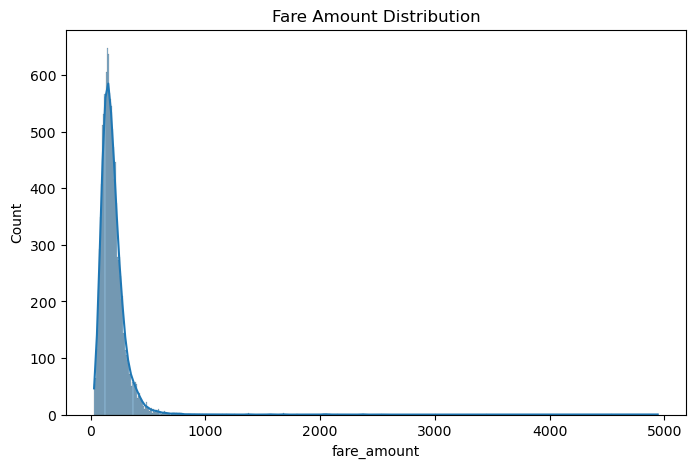

In [ ]:
#Fare Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["fare_amount"], kde=True)
plt.title("Fare Amount Distribution")
plt.show()

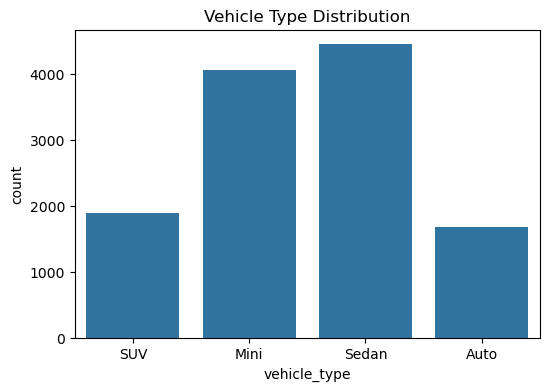

In [ ]:
#Vechile Type Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="vehicle_type")
plt.title("Vehicle Type Distribution")
plt.show()

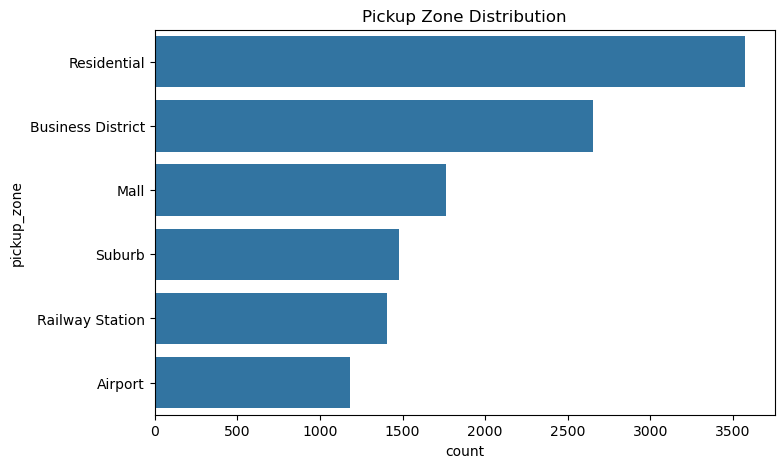

In [ ]:
#Pickup Zone Distribution
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    y="pickup_zone",
    order=df["pickup_zone"].value_counts().index
)

plt.title("Pickup Zone Distribution")
plt.show()

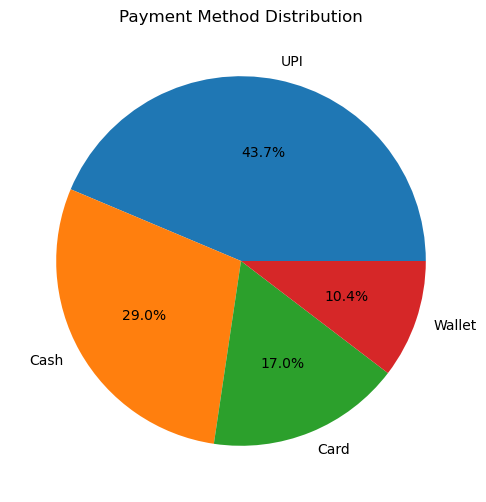

In [ ]:
#Payment Method Distrubution
payment_counts = df["payment_method"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.show()

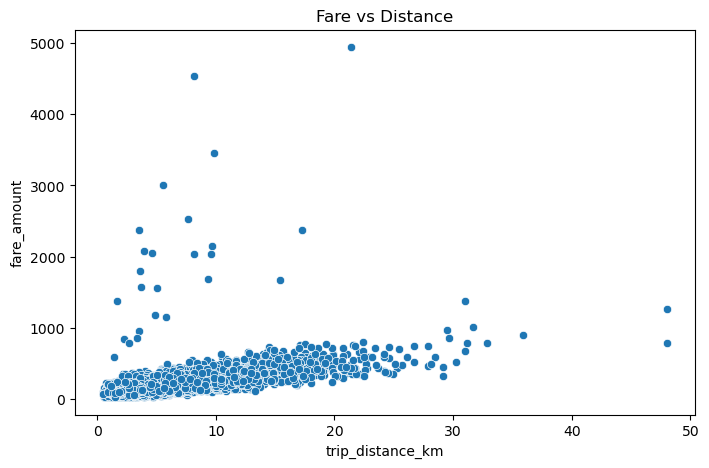

In [22]:
#Fare VS Distance
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="trip_distance_km",
    y="fare_amount"
)

plt.title("Fare vs Distance")
plt.show()

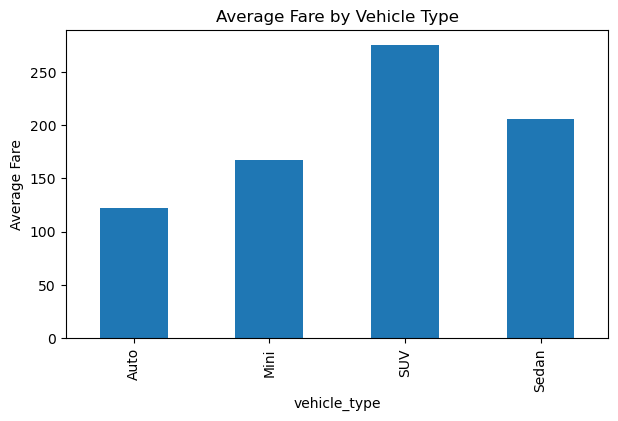

In [23]:
#Average Fare by Vechile Type
avg_fare = df.groupby("vehicle_type")["fare_amount"].mean()

avg_fare.plot(
    kind="bar",
    figsize=(7,4)
)

plt.ylabel("Average Fare")
plt.title("Average Fare by Vehicle Type")
plt.show()

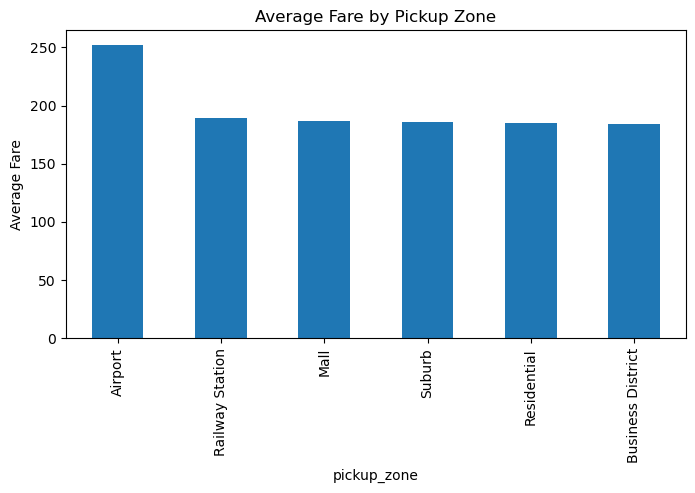

In [24]:
#Average Fare by PickUp Zone
zone_fare = (
    df.groupby("pickup_zone")["fare_amount"]
    .mean()
    .sort_values(ascending=False)
)

zone_fare.plot(
    kind="bar",
    figsize=(8,4)
)

plt.ylabel("Average Fare")
plt.title("Average Fare by Pickup Zone")
plt.show()

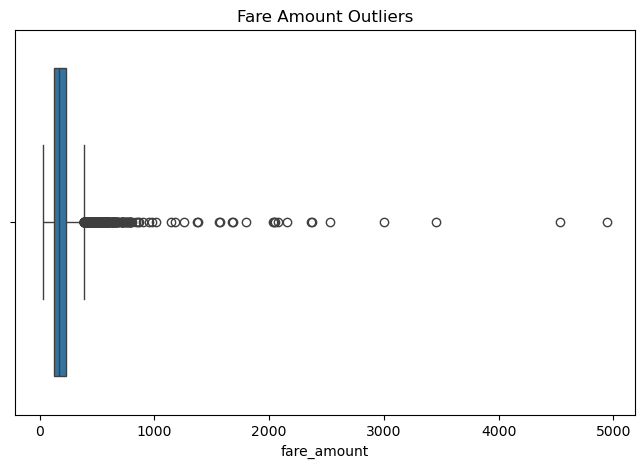

In [25]:
#Outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["fare_amount"]
)

plt.title("Fare Amount Outliers")
plt.show()

In [ ]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["hour"] = df["pickup_datetime"].dt.hour
df["day"] = df["pickup_datetime"].dt.day
df["month"] = df["pickup_datetime"].dt.month
df["weekday"] = df["pickup_datetime"].dt.day_name()

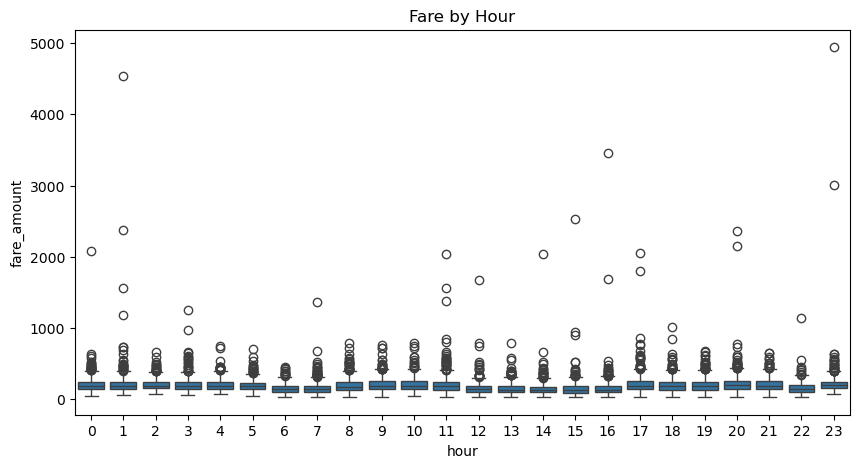

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="hour",
    y="fare_amount"
)

plt.title("Fare by Hour")
plt.show()

In [28]:
X = df.drop(['fare_amount','trip_id','pickup_datetime'], axis=1)
y = df['fare_amount']

In [29]:
X.sample(3)

,pickup_zone,vehicle_type,passenger_count,trip_distance_km,trip_duration_min,payment_method,hour,day,month,weekday
545,Business District,Sedan,1,3.92,16.2,Wallet,21,17,10,Thursday
11485,Residential,Auto,1,2.68,10.4,Wallet,1,24,10,Thursday
1176,Airport,Sedan,3,6.08,19.3,Cash,13,30,4,Tuesday


In [30]:
y.sample(3)

11038    138.41
2452     169.00
3992     140.93
Name: fare_amount, dtype: float64

In [32]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [33]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])


In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [36]:
X_train.sample(3)

,pickup_zone,vehicle_type,passenger_count,trip_distance_km,trip_duration_min,payment_method,hour,day,month,weekday
9027,Suburb,SUV,1,1.33,6.7,Cash,8,26,12,Thursday
3520,Business District,Sedan,4,2.52,14.7,UPI,10,4,4,Thursday
3792,Railway Station,Auto,2,3.99,10.4,Cash,23,14,8,Wednesday


In [38]:
X_test.sample(3)

,pickup_zone,vehicle_type,passenger_count,trip_distance_km,trip_duration_min,payment_method,hour,day,month,weekday
4502,Residential,SUV,2,1.89,5.8,Wallet,22,18,4,Friday
9870,Suburb,SUV,1,1.44,11.6,UPI,19,15,4,Monday
2846,Airport,Mini,1,10.15,29.0,UPI,2,22,2,Saturday


In [39]:
y_train.sample(3)

8004     179.05
5008     106.40
10128    165.72
Name: fare_amount, dtype: float64

In [41]:
y_test.sample(3)

8949    278.03
598     292.83
7198    172.43
Name: fare_amount, dtype: float64

In [42]:

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = r2_score(y_test, preds)

results

{'Linear Regression': 0.4151741802331448,
 'Decision Tree': 0.26144786324628233,
 'Random Forest': 0.41758821728240025}

In [43]:
import joblib

best_name = max(results, key=results.get)
best_model = Pipeline([('prep', preprocessor), ('model', models[best_name])])
best_model.fit(X_train, y_train)

joblib.dump(best_model, 'best_taxi_model.pkl')
print('Saved:', best_name)

Saved: Random Forest
